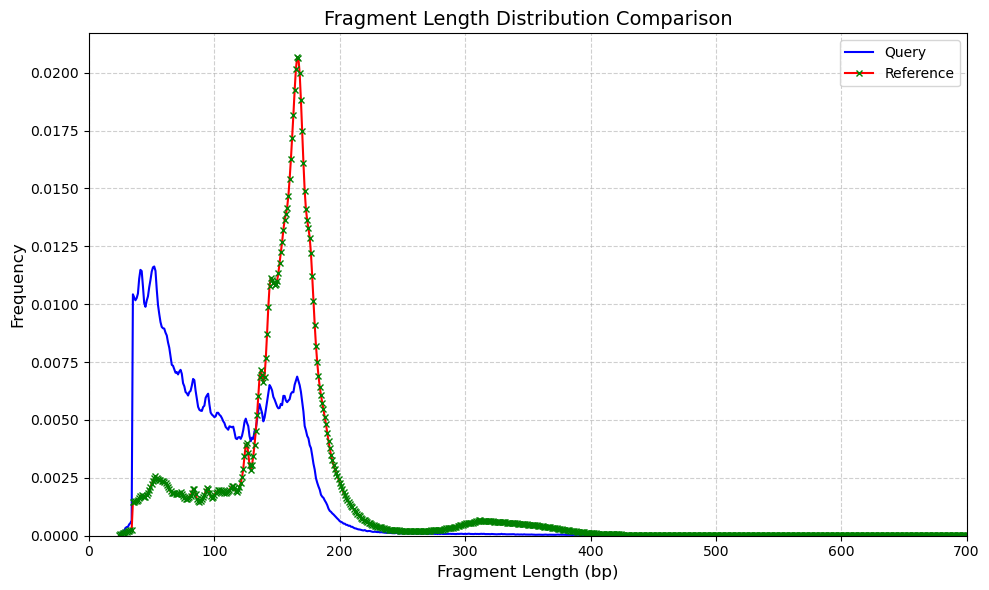

In [26]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

def calculate_fragment_lengths(bed_file):
    lengths = []
    with gzip.open(bed_file, 'rt') as f:
        for line in f:
            parts = line.strip().split()
            start = int(parts[1])
            end = int(parts[2])
            lengths.append(end - start)
    return lengths

def plot_comparison(query_lengths, reference_hist_file, output_file='rescale_output.png'):
    ref_bins = []
    ref_counts = []
    with open(reference_hist_file, 'r') as f:
        for line in f:
            if not line.startswith('#'):
                parts = line.strip().split()
                if len(parts) >= 2:
                    ref_bins.append(float(parts[0]))
                    ref_counts.append(float(parts[1]))
    
   
    ref_bins = np.array(ref_bins)
    ref_counts = np.array(ref_counts)
    total_ref_counts = np.sum(ref_counts)
    
    if len(ref_bins) > 1:
        bin_width = ref_bins[1] - ref_bins[0]
        ref_bin_edges = np.concatenate([ref_bins, [ref_bins[-1] + bin_width]])
    else:
        ref_bin_edges = np.array([ref_bins[0], ref_bins[0] + 1])
    
    query_counts, _ = np.histogram(query_lengths, bins=ref_bin_edges)
    query_normalized = query_counts / np.sum(query_counts)
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(ref_bins, query_normalized, 'b-', linewidth=1.5,
            label='Query')
    
    plt.plot(ref_bins, ref_counts, 'r-', linewidth=1.5,
            marker='x', markersize=5, markeredgecolor='g', markerfacecolor='g',
            label='Reference')
    
    plt.xlabel('Fragment Length (bp)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Fragment Length Distribution Comparison', fontsize=14)
    
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.ylim(bottom=0)  
    plt.xlim(0, 700)
    plt.xticks(np.arange(0, 701, 100))
    
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Main execution
query_lengths = calculate_fragment_lengths('query.bed.gz')
plot_comparison(query_lengths, 'reference.hist')